# Interactive Reinforcement Learning Simulation 🩺

Run the cells below to initialize the simulation and step through it interactively using your own custom inputs for the insulin pump dosages, or pass the baton to the trained Q-Learning AI!

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pickle
from simulation import InsulinEnv, plot_episode
from IPython.display import display, clear_output

import warnings
warnings.filterwarnings('ignore')

# Load the Q-table
with open('qtable.pkl', 'rb') as f:
    Q = pickle.load(f)

# Initialize the environment
env = InsulinEnv(patient_name='adult#001', seed=42)
state = env.reset()
print("Environment ready! Proceed to the next cell to run the interaction loop.")

Environment ready! Proceed to the next cell to run the interaction loop.


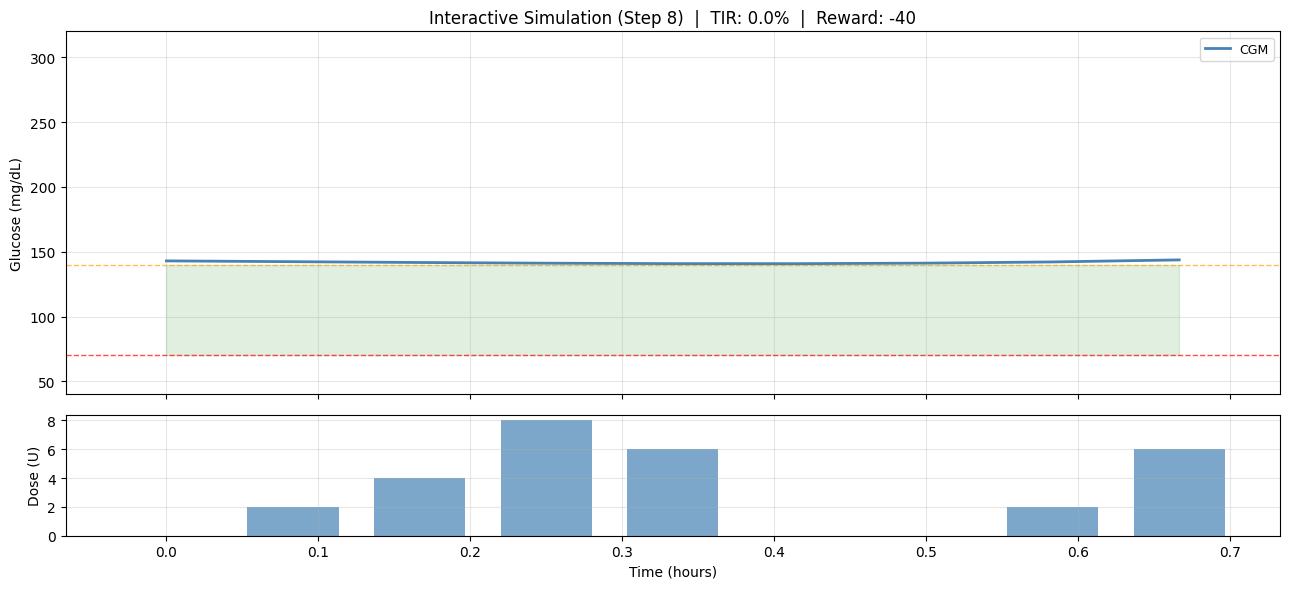


--- Step 8 ---
Current BG: 143.7 mg/dL
Recent Doses: [6, 0, 0, 2, 6]


KeyboardInterrupt: Interrupted by user

In [ ]:
done = False
step_counter = 0

while not done and step_counter < 50:
    clear_output(wait=True)
    
    # Render the entire history up to this point using our custom plotter!
    plot_episode(env, title=f'Interactive Simulation (Step {step_counter})')
    
    # Get user input
    print(f"\n--- Step {step_counter} ---")
    print(f"Current BG: {env.glucose_history[-1]:.1f} mg/dL")
    print(f"Recent Doses: {env.dose_history[-5:]}")
    user_input = input("Enter dose (0, 2, 4, 6, 8), 'q' for AI, or 'exit' to stop: ")
    
    if user_input.lower() == 'exit':
        print("Simulation stopped by user.")
        break
        
    if user_input.lower() == 'q':
        action_idx = int(np.argmax(Q[state]))
        print(f"AI Agent selected dose: {env.ACTIONS[action_idx]}U")
    else:
        try:
            val = float(user_input)
            action_idx = np.argmin(np.abs(np.array(env.ACTIONS) - val))
            print(f"You manually selected dose: {env.ACTIONS[action_idx]}U")
        except ValueError:
            print("Invalid input, defaulting to AI.")
            action_idx = int(np.argmax(Q[state]))
            
    state, reward, done = env.step(action_idx)
    step_counter += 1

if done:
    clear_output(wait=True)
    plot_episode(env, title=f'Final Simulation State (Step {step_counter})')
    print("Simulation ended (Episode Complete). Patient reached terminal state.")